# 🤖 Forensic Glass Identification — Step 4: Model Building

**Project design step 4 of 5** (Research → Planning → EDA → **Model building** → Modularization)

The plan, driven by what the EDA found:

1. Split the data (stratified) and lock the test set away until the very end
2. Establish a **baseline** so we know what "better than nothing" means
3. Compare many models with **repeated stratified cross-validation**, scored by **macro-F1**
4. Run three small experiments: engineered features, imbalance handling, tuning
5. Evaluate **once** on the test set and check how much that number depends on the split
6. Interpret the model (what does it rely on?)
7. Optional advanced ideas: merging classes, probability calibration, ensembling

> **Golden rules used throughout**
> * Scaling, feature engineering and SMOTE live **inside the Pipeline**, so they are fitted on each training fold only (no leakage).
> * The **test set is touched once**. Every decision (model choice, hyper-parameters) is made with cross-validation on the training data.
> * With 213 rows, differences smaller than the fold-to-fold noise (the ± std) are **not** real differences.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Find the project root (the folder containing `src/`) so imports work
# no matter where Jupyter was started from.
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "src").exists(), (
    "Open this notebook from inside the glass-forensics project folder (it needs the `src/` package).")
sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.precision", 3)
RANDOM_STATE = 42

import tempfile
import joblib
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_validate
from imblearn.ensemble import BalancedRandomForestClassifier

from src.config import FEATURES, TARGET, CLASS_NAMES, MODEL_PATH
from src.data_loader import load_data
from src.preprocess import get_X_y, split_data
from src.models import get_models, make_pipeline, get_param_grid
from src.evaluate import (compare_models, make_cv, plot_model_comparison, test_report,
                          plot_confusion_matrix, compute_permutation_importance,
                          plot_permutation_importance)

LABELS = {c: f"{c}: {n}" for c, n in CLASS_NAMES.items()}

## 1. Load, de-duplicate and split

We drop the one duplicate row found in the EDA, then make an 80/20 **stratified** split. Everything below uses `X_train` / `y_train` only, until section 6.

In [2]:
df = load_data(drop_duplicates=True)
X, y = get_X_y(df)
X_train, X_test, y_train, y_test = split_data(X, y)          # stratified, random_state=42

split_table = pd.DataFrame({"train": y_train.value_counts(), "test": y_test.value_counts()}).sort_index()
split_table.index = [LABELS[c] for c in split_table.index]
split_table.loc["TOTAL"] = split_table.sum()
split_table

,train,test
1: Building windows (float),55,14
2: Building windows (non-float),61,15
3: Vehicle windows (float),14,3
5: Containers,10,3
6: Tableware,7,2
7: Headlamps,23,6
TOTAL,170,43


> Every class appears in both parts, thanks to stratification. But notice the test set has only **2–3 samples** of types 3, 5 and 6, so one misclassified
> sample changes those classes' scores dramatically. Keep this in mind in section 6.

## 2. Baseline and model comparison

**Repeated stratified 5-fold CV** (5 folds × 3 repeats = 15 scores per model) is more stable than a single 5-fold run on ~170 rows.
The first row of the table is a `DummyClassifier` that always predicts the most common class: the floor every real model must beat.

In [3]:
cv = make_cv()                      # RepeatedStratifiedKFold(5 splits, 3 repeats, seed 42)
models = get_models()               # every model = StandardScaler -> classifier, in one Pipeline
results = compare_models(models, X_train, y_train, cv=cv)
results.round(3)

,model,f1_macro,f1_macro_std,accuracy,balanced_accuracy,fit_time_s
0,Random Forest + SMOTE,0.717,0.047,0.753,0.752,0.358
1,Random Forest,0.703,0.068,0.767,0.707,0.315
2,Extra Trees,0.686,0.091,0.771,0.693,0.250
3,Decision Tree,0.634,0.059,0.627,0.658,0.004
4,SVM (RBF),0.620,0.076,0.610,0.630,0.009
5,Logistic Regression,0.619,0.056,0.563,0.676,0.006
6,Gradient Boosting,0.580,0.087,0.731,0.600,0.430
7,KNN,0.552,0.103,0.659,0.568,0.003
8,Dummy (most frequent),0.088,0.002,0.359,0.167,0.003


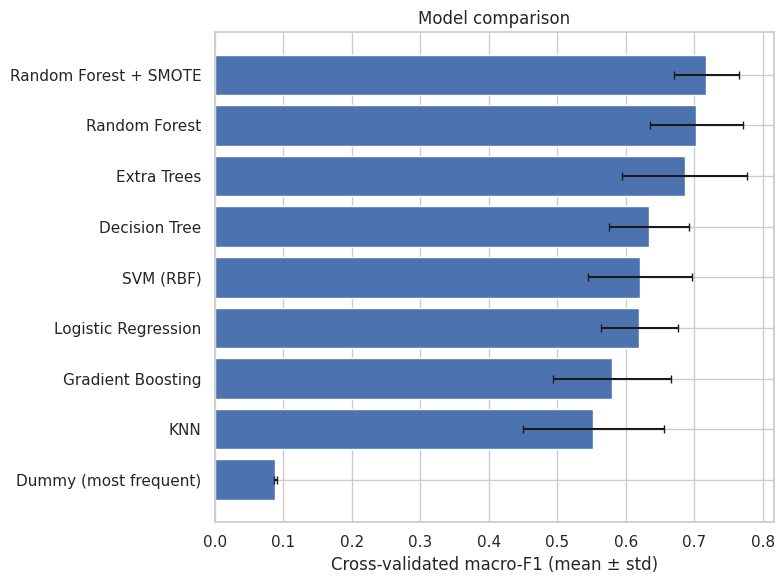

In [4]:
plot_model_comparison(results); plt.show()

> **Key insight — model comparison**
> * **Baseline:** always guessing the majority class gets 36% accuracy but a macro-F1 of only **0.09**. Every real model beats it easily.
> * The **forests lead** (RF + SMOTE 0.72, Random Forest 0.70, Extra Trees 0.69); single models sit around 0.55–0.63. But the fold-to-fold std is 0.05–0.09,
>   so the three forests are **statistically indistinguishable**. Choose between them on simplicity and stability, not on the third decimal.
> * **Accuracy can mislead:** Gradient Boosting has a higher accuracy (0.73) than SVM (0.61) or logistic regression (0.56), yet one of the lowest macro-F1 scores (0.58). It has no class weighting, so it likely
>   does well on the big classes and neglects the rare ones. This is exactly why we score with macro-F1.
> * Why forests? The class boundaries here are irregular and threshold-like ("Ba > 0", "Mg = 0"), which suits trees better than the smooth boundaries of linear models, SVMs or KNN.

## 3. Experiment: do the engineered features help?

The EDA suggested Ca/Na and Mg/Al ratios, a Ba-present flag, a Mg-is-zero flag and `log1p` of skewed oxides (`src/preprocess.py → add_features`).
We test them properly: the **same CV folds**, with and without the features.

In [5]:
subset = ["Logistic Regression", "SVM (RBF)", "Random Forest", "Extra Trees"]
eng_models = {n: m for n, m in get_models(engineer=True).items() if n in subset}
eng = compare_models(eng_models, X_train, y_train, cv=cv).set_index("model")
raw = results.set_index("model").loc[subset]

ablation = pd.DataFrame({
    "raw features": raw["f1_macro"],
    "+ engineered": eng.loc[subset, "f1_macro"],
    "fold-to-fold std": raw["f1_macro_std"],
})
ablation["difference"] = ablation["+ engineered"] - ablation["raw features"]
ablation.round(3)

,raw features,+ engineered,fold-to-fold std,difference
model,,,,
Logistic Regression,0.619,0.626,0.056,0.007
SVM (RBF),0.620,0.590,0.076,-0.030
Random Forest,0.703,0.682,0.068,-0.021
Extra Trees,0.686,0.686,0.091,0.000


> **Key insight — engineered features: no evidence they help**
> * The differences are +0.007, −0.030, −0.021 and 0.000. All are far smaller than the fold-to-fold std (0.056–0.091), so they are noise. For SVM and Random Forest the sign is even negative.
> * Why? Trees are unaffected by monotonic transforms like `log1p`, and can already learn thresholds such as "Ba > 0" or "Mg = 0" on their own. With ~170 training rows, extra features mostly add noise.
> * **Decision:** keep the simpler raw-feature pipeline (the default in `src/models.py`). A clean negative result is still a result, and worth stating in the README.

## 4. Experiment: how should we handle class imbalance?

Options: do nothing, `class_weight="balanced"` (rare-class errors cost more), **SMOTE** (synthesise extra minority samples *inside each training fold only*),
or a **Balanced Random Forest** (each tree sees a class-balanced bootstrap sample).

In [6]:
imb_models = {
    "RF, no weighting": make_pipeline(RandomForestClassifier(n_estimators=300, random_state=42)),
    "RF, class_weight='balanced'": models["Random Forest"],
    "RF + SMOTE": models["Random Forest + SMOTE"],
    "Balanced Random Forest": make_pipeline(BalancedRandomForestClassifier(n_estimators=300, random_state=42)),
}
imb = compare_models(imb_models, X_train, y_train, cv=cv)
imb.round(3)

,model,f1_macro,f1_macro_std,accuracy,balanced_accuracy,fit_time_s
0,"RF, no weighting",0.741,0.073,0.784,0.744,0.306
1,RF + SMOTE,0.717,0.047,0.753,0.752,0.351
2,"RF, class_weight='balanced'",0.703,0.068,0.767,0.707,0.309
3,Balanced Random Forest,0.646,0.081,0.649,0.719,0.460


> **Key insight — imbalance handling is not a magic fix here**
> * Surprisingly, the **plain forest with no rebalancing scores highest (0.741)**; SMOTE (0.717) and class weights (0.703) don't beat it. Gaps of ≤ 0.04 are inside the noise (std 0.05–0.08).
> * The **Balanced Random Forest is worst** (0.646): each tree is trained on a tiny balanced sample (about as many rows per class as the rarest class has, ~7), so the individual trees are weak.
> * SMOTE gives the **most stable** result (lowest std, 0.047) and the best balanced accuracy (0.752), which is why it topped the section-2 table.
> * We keep the pre-planned procedure (tune the top two from section 2) rather than switching after seeing more comparisons. Picking the best of many noisy comparisons is how you overfit your cross-validation.
>   A plain forest would be an equally defensible final choice.

## 5. Hyper-parameter tuning

We tune the **top two** models from section 2 with `GridSearchCV`, scored by macro-F1. Grids are defined in `src/models.py`.

In [7]:
top2 = results[~results["model"].str.startswith("Dummy")]["model"].head(2).tolist()
inner_cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

tuned = {}
for name in top2:
    gs = GridSearchCV(models[name], get_param_grid(name), scoring="f1_macro", cv=inner_cv, refit=True)
    gs.fit(X_train, y_train)
    tuned[name] = gs
    print(f"{name}\n   best CV macro-F1 = {gs.best_score_:.3f}\n   params = {gs.best_params_}")

best_name = max(tuned, key=lambda n: tuned[n].best_score_)
best = tuned[best_name].best_estimator_
print(f"\nSelected: {best_name}")

Random Forest + SMOTE
   best CV macro-F1 = 0.757
   params = {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}


Random Forest
   best CV macro-F1 = 0.737
   params = {'clf__max_depth': 10, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}

Selected: Random Forest + SMOTE


In [8]:
summary = pd.DataFrame({
    "before tuning (repeated CV)": results.set_index("model").loc[top2, "f1_macro"],
    "after tuning (grid-search CV)": pd.Series({n: g.best_score_ for n, g in tuned.items()}),
})
summary.round(3)

,before tuning (repeated CV),after tuning (grid-search CV)
Random Forest + SMOTE,0.717,0.757
Random Forest,0.703,0.737


**A subtle trap:** the "after tuning" score is the *maximum* over many hyper-parameter combinations, so it is an optimistically biased estimate.
The honest way to measure "tune + evaluate" is **nested cross-validation**: tune inside each outer training fold, score on the outer validation fold.
Here is a light version (reduced grid so it runs in about a minute):

In [9]:
grid = get_param_grid(best_name)
small_grid = {k: v[:2] for k, v in list(grid.items())[:2]}
nested = cross_val_score(
    GridSearchCV(clone(models[best_name]), small_grid, scoring="f1_macro",
                 cv=StratifiedKFold(3, shuffle=True, random_state=1)),
    X_train, y_train, scoring="f1_macro",
    cv=StratifiedKFold(5, shuffle=True, random_state=7))
print(f"Nested-CV macro-F1: {nested.mean():.3f} ± {nested.std():.3f}   (per fold: {nested.round(2)})")
print(f"Grid-search 'best score' (optimistic): {tuned[best_name].best_score_:.3f}")

Nested-CV macro-F1: 0.691 ± 0.107   (per fold: [0.57 0.56 0.78 0.81 0.74])
Grid-search 'best score' (optimistic): 0.757


> **Key insight — tuning helps less than it appears**
> * Grid search lifted CV macro-F1 from 0.717 → 0.757 (RF + SMOTE) and 0.703 → 0.737 (RF). But that figure is the **best of 16 tries**, so it flatters the model.
> * **Nested CV gives 0.69 ± 0.11** (individual folds range from 0.56 to 0.81), no better than the untuned model. (Caveat: a reduced grid and different folds, so compare loosely.)
>   The message is that on ~170 rows, tuning buys little real improvement; part of the gain is fitting noise.
> * A realistic expectation for this problem is a **macro-F1 of roughly 0.70–0.75**.
> * Selected model: **RF + SMOTE** (`max_depth=10`, `max_features="sqrt"`, 200 trees).

## 6. Final evaluation on the held-out test set (used once)

Now, and only now, we score the tuned model on the test set.

In [10]:
metrics = test_report(best, X_test, y_test)
print({k: round(v, 3) for k, v in metrics.items() if k != "per_class"})

                                 precision    recall  f1-score   support

    1: Building windows (float)       0.92      0.79      0.85        14
2: Building windows (non-float)       0.80      0.80      0.80        15
     3: Vehicle windows (float)       0.60      1.00      0.75         3
                  5: Containers       1.00      1.00      1.00         3
                   6: Tableware       0.67      1.00      0.80         2
                   7: Headlamps       1.00      0.83      0.91         6

                       accuracy                           0.84        43
                      macro avg       0.83      0.90      0.85        43
                   weighted avg       0.86      0.84      0.84        43

{'accuracy': 0.837, 'balanced_accuracy': 0.903, 'f1_macro': 0.851, 'f1_weighted': 0.841}


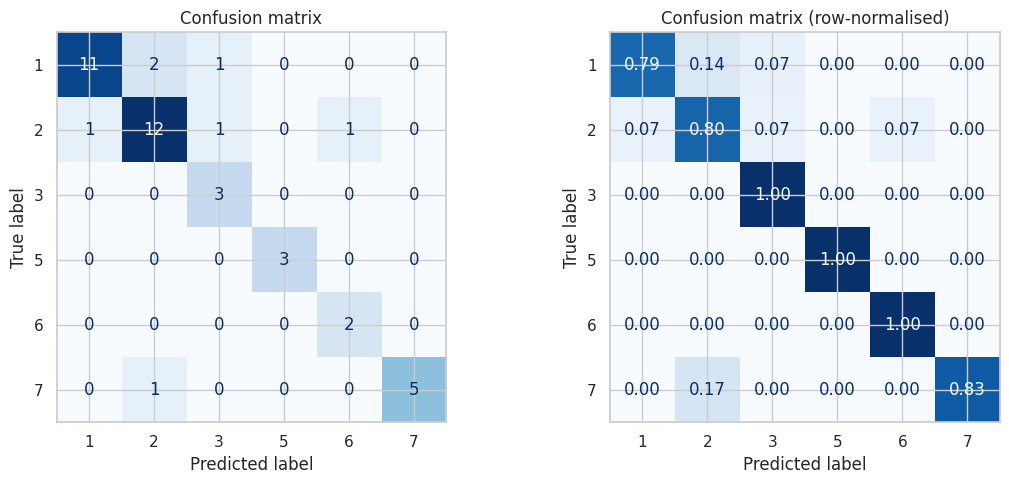

Misclassified test samples (true -> predicted):
                count
true predicted       
1    2              2
2    1              1
     6              1
     3              1
7    2              1
1    3              1


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(best, X_test, y_test, ax=axes[0])
plot_confusion_matrix(best, X_test, y_test, normalize="true", ax=axes[1])
plt.show()

pred = pd.Series(best.predict(X_test), index=y_test.index)
wrong = pd.DataFrame({"true": y_test[pred != y_test], "predicted": pred[pred != y_test]})
print("Misclassified test samples (true -> predicted):")
print(wrong.value_counts().rename("count").to_frame().to_string())

> **Key insight — test-set results**
> * On this split: accuracy **0.84**, macro-F1 **0.85**, balanced accuracy 0.90. That is *higher* than every cross-validation estimate (≈ 0.72–0.76), which should make us suspicious of a lucky split. Section 7 checks.
> * 7 of 43 samples are wrong, and **5 of the 7 are confusions among the three window types** (1→2 twice, 2→1, 1→3, 2→3), exactly as the EDA predicted. Type 3's precision is only 0.60 because 2 of the 5 "type 3" predictions were really types 1 and 2.
> * The other two errors: one type-2 sample predicted as tableware, and one headlamp predicted as type 2.
> * Perfect scores for types 5 and 6 come from just 3 and 2 test samples, so they carry very little statistical weight.

## 7. How much does the test score depend on the split?

The test set has 43 samples and some classes only 2–3. What if we had drawn a different split? We re-split with 30 different seeds, refit the tuned model
(hyper-parameters fixed) on each training part, and score each test part.

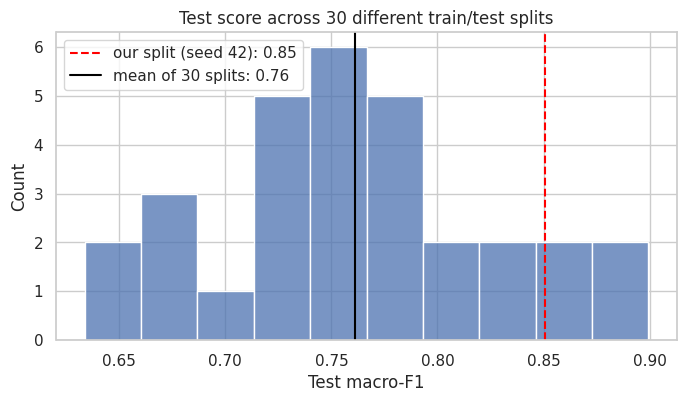

macro-F1 over 30 splits: mean 0.761, std 0.066, min 0.634, max 0.899


In [12]:
split_scores = []
for seed in range(30):
    Xa, Xb, ya, yb = split_data(X, y, random_state=seed)
    m = clone(best).fit(Xa, ya)
    split_scores.append(f1_score(yb, m.predict(Xb), average="macro"))
split_scores = np.array(split_scores)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(split_scores, bins=10, color="#4C72B0", ax=ax)
ax.axvline(metrics["f1_macro"], color="red", ls="--", label=f"our split (seed 42): {metrics['f1_macro']:.2f}")
ax.axvline(split_scores.mean(), color="black", ls="-", label=f"mean of 30 splits: {split_scores.mean():.2f}")
ax.set_xlabel("Test macro-F1"); ax.set_title("Test score across 30 different train/test splits"); ax.legend()
plt.show()
print(f"macro-F1 over 30 splits: mean {split_scores.mean():.3f}, std {split_scores.std():.3f}, "
      f"min {split_scores.min():.3f}, max {split_scores.max():.3f}")

> **Key insight — one test score is a noisy number**
> * Across 30 different splits, macro-F1 ranges from **0.63 to 0.90** (mean 0.76, std 0.07). Our 0.85 sits in the upper tail: it was a **favourable split**.
> * What to report: *"macro-F1 ≈ 0.70–0.76, varying by ±0.07 depending on the split"*, not "0.85".
> * Caveat: the hyper-parameters were tuned on the seed-42 training set, and other splits' test rows overlap with it, so even the 0.76 mean is slightly optimistic. That's one more reason to trust the more conservative nested-CV number.

## 8. Interpretation: what is the model relying on?

Two views: **permutation importance** (shuffle one feature on the test set and see how much macro-F1 drops; works for any model) and the forest's own
**impurity-based importance** (computed on training data; can favour features with many distinct values).

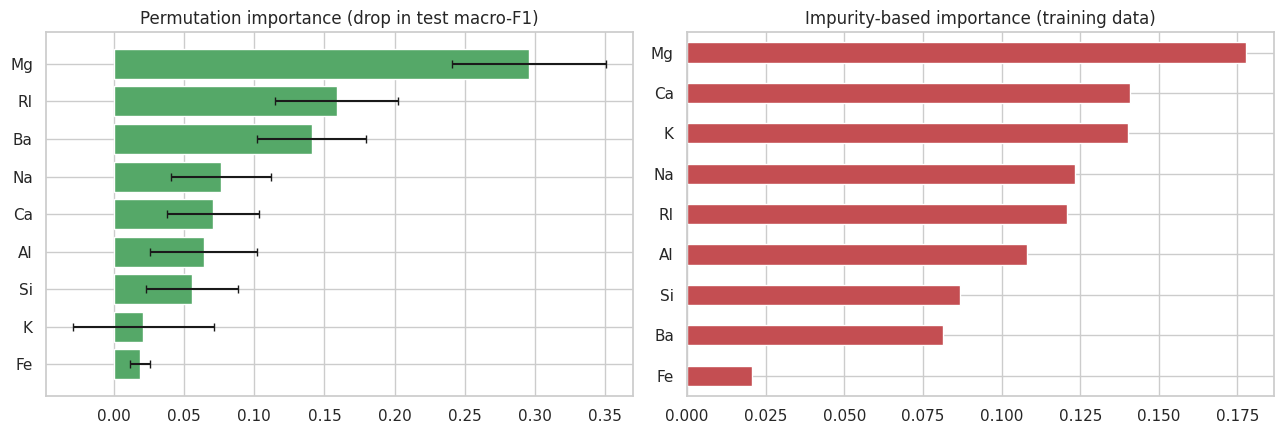

,0,1,2,3,4,5,6,7,8
feature,Mg,RI,Ba,Na,Ca,Al,Si,K,Fe
importance,0.296,0.159,0.141,0.076,0.071,0.064,0.056,0.021,0.019
std,0.055,0.044,0.039,0.036,0.033,0.038,0.033,0.05,0.007


In [13]:
imp = compute_permutation_importance(best, X_test, y_test, n_repeats=30)
clf = best.named_steps["clf"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d = imp.sort_values("importance")
axes[0].barh(d["feature"], d["importance"], xerr=d["std"], color="#55A868", capsize=3)
axes[0].set_title("Permutation importance (drop in test macro-F1)")
if hasattr(clf, "feature_importances_"):
    pd.Series(clf.feature_importances_, index=FEATURES).sort_values().plot.barh(ax=axes[1], color="#C44E52")
    axes[1].set_title("Impurity-based importance (training data)")
else:
    axes[1].axis("off")
plt.tight_layout(); plt.show()
imp.round(3).T

> **Key insight — what the model relies on**
> * Both methods put **Mg first**. Permutation importance ranks **Mg (0.30), RI (0.16) and Ba (0.14)** clearly ahead; Na, Ca, Al and Si are similar to each other (their error bars overlap), and **K and Fe contribute almost nothing**.
> * This matches the EDA: Mg separates windows from non-windows and Ba marks headlamps. RI's importance is a new finding. It plausibly helps separate the window subtypes, whose chemistry is otherwise near-identical.
> * The two methods **disagree about K and Ba**: impurity importance ranks K third and Ba second-to-last, permutation says the opposite. Impurity importance is computed on training data and favours continuous
>   features with many split points. Ba is mostly zero, so it rarely splits, but when it does it is decisive for headlamps. Prefer permutation importance, remembering that 43 test samples make it noisy (see error bars).

## 9. Advanced experiments (optional)

### 9a. Where exactly is the difficulty? Merge classes
If the model's main problem is telling **type 1 from type 2**, then merging them (or simplifying the task) should raise the score a lot.
*These are different tasks, so the numbers are not a fair leaderboard. They diagnose where the errors come from.*

In [14]:
tasks = {
    "Original: 6 classes": y_train,
    "Merge types 1 & 2 (5 classes)": y_train.replace({2: 1}),
    "Window vs non-window (2 classes)": y_train.isin([1, 2, 3]).astype(int),
}
rows = []
for name, target in tasks.items():
    r = cross_validate(clone(best), X_train, target, cv=cv, scoring=["f1_macro", "balanced_accuracy"])
    rows.append({"task": name, "macro-F1": r["test_f1_macro"].mean(), "balanced accuracy": r["test_balanced_accuracy"].mean()})
pd.DataFrame(rows).round(3)

,task,macro-F1,balanced accuracy
0,Original: 6 classes,0.725,0.753
1,Merge types 1 & 2 (5 classes),0.739,0.744
2,Window vs non-window (2 classes),0.923,0.924


> **Key insight — where the difficulty really is**
> * Merging types 1 and 2 barely changes the score (0.725 → 0.739), so the hypothesis *"the model's only problem is 1 vs 2"* is **not supported**.
>   Type 3 (float vehicle glass) is also confused with type 1 (both float glass), and the rare classes add noise. The difficulty is spread across all the window subtypes.
>   (The 6-class number is a bit above section 2's because these hyper-parameters were tuned on this same data.)
> * The **window vs non-window** task scores **0.92**. Chemistry separates glass *families* (windows vs containers, headlamps, tableware) reliably, but not the fine subtypes within window glass.
>   That is an honest limit of the data: nine oxide values and RI just don't carry enough information to tell those subtypes apart.
> * Practically: if a user only needs a family-level answer, a coarse model would be far more reliable than the 6-class one.

### 9b. Probability calibration
In forensics, *how confident* the model is matters as much as its label. Is a "70% confident" prediction right about 70% of the time?
We compare **log-loss** (lower is better; punishes confident mistakes) of the model as-is against a **sigmoid-calibrated** version.

In [15]:
ll_cv = StratifiedKFold(5, shuffle=True, random_state=0)
raw_ll = -cross_val_score(clone(best), X_train, y_train, cv=ll_cv, scoring="neg_log_loss")
cal_ll = -cross_val_score(CalibratedClassifierCV(clone(best), method="sigmoid", cv=3),
                          X_train, y_train, cv=ll_cv, scoring="neg_log_loss")
print(f"log-loss, uncalibrated: {raw_ll.mean():.3f} ± {raw_ll.std():.3f}")
print(f"log-loss, calibrated  : {cal_ll.mean():.3f} ± {cal_ll.std():.3f}")

log-loss, uncalibrated: 0.915 ± 0.610
log-loss, calibrated  : 0.785 ± 0.191


> **Key insight — calibration**
> * Sigmoid calibration lowered the mean log-loss from 0.92 to 0.79 and, more importantly, cut its variability sharply (std 0.61 → 0.19). The raw forest is likely giving near-zero probability to the true class in a few
>   cases, and a single such over-confident mistake is penalised heavily; calibration softens those outputs.
> * With 5 folds and few rare-class samples this is indicative, not conclusive. But in a forensic setting, honest probabilities matter: if you show a "confidence" to a user, the calibrated version is the better choice
>   (a natural extension: add a `--calibrate` option to `train.py`).

### 9c. Ensembling: soft voting
Average the predicted probabilities of three different model families (forest, SVM, logistic regression). Diverse models sometimes make different mistakes.

In [16]:
voting = VotingClassifier(
    [("rf", clone(models["Random Forest"])), ("svm", clone(models["SVM (RBF)"])),
     ("lr", clone(models["Logistic Regression"]))], voting="soft")
ens = compare_models({"Soft voting (RF + SVM + LR)": voting}, X_train, y_train, cv=cv)
pd.concat([ens, results[results["model"].isin(["Random Forest", "SVM (RBF)", "Logistic Regression"])]]).round(3)

,model,f1_macro,f1_macro_std,accuracy,balanced_accuracy,fit_time_s
0,Soft voting (RF + SVM + LR),0.683,0.062,0.743,0.703,0.326
1,Random Forest,0.703,0.068,0.767,0.707,0.315
4,SVM (RBF),0.620,0.076,0.610,0.630,0.009
5,Logistic Regression,0.619,0.056,0.563,0.676,0.006


> **Key insight — ensembling didn't help here**
> Soft voting (0.683) does not beat the Random Forest alone (0.703). SVM and logistic regression are much weaker (≈ 0.62) and drag the average down.
> Ensembles help when the members are individually strong *and* make different mistakes; here only the forest is strong.

## 10. Saving the model (round-trip check)

`joblib` saves the **entire pipeline** (scaler + classifier), so predictions on raw measurements work after reloading with no extra code.
The production version of this step is `python -m src.train`, which also writes the metadata file the demo app needs.

In [17]:
from src.predict import predict

with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "glass_model.joblib"
    joblib.dump(best, path)
    reloaded = joblib.load(path)
print("Reloaded model gives identical predictions:", bool((reloaded.predict(X_test) == best.predict(X_test)).all()))

# A brand-new measurement, e.g. a fragment with barium and no magnesium
new_sample = {"RI": 1.5165, "Na": 14.38, "Mg": 0.0, "Al": 1.94, "Si": 73.61, "K": 0.0, "Ca": 8.48, "Ba": 1.57, "Fe": 0.0}
predict(reloaded, new_sample).round(3)

Reloaded model gives identical predictions: True


,predicted_type,description,confidence,P(type 1),P(type 2),P(type 3),P(type 5),P(type 6),P(type 7)
0,7,Headlamps,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## 11. Summary of results

| Question | What we found |
|---|---|
| Baseline | Always guessing the majority class: macro-F1 **0.09**, accuracy 36% |
| Best model family | **Random forests**: CV macro-F1 ≈ **0.70–0.74**, accuracy ≈ 75–78% |
| Engineered features | **No gain** (differences well inside the noise) → kept the simpler raw pipeline |
| Imbalance handling | No clear gain over a plain forest; SMOTE gives the most *stable* score |
| Hyper-parameter tuning | Little real gain: grid-search 0.757 is optimistic, nested CV ≈ 0.69 |
| Test set (one split) | accuracy 0.84, macro-F1 0.85, a **favourable split**; the 30-split mean is **0.76 ± 0.07** |
| Where the errors are | Mostly among window types 1, 2, 3. Window vs non-window is easy (≈ 0.92) |
| Most important features | **Mg, RI, Ba** (K and Fe contribute almost nothing) |
| Calibration | Helps: lower and much more stable log-loss |
| Ensembling | No gain |

**Honest headline:** on this small dataset, expect a macro-F1 of roughly **0.70–0.76** and accuracy of about **75–80%**. Claims of 95%+ on the UCI glass data should make you ask about leakage
or duplicated rows.

### Where to go from here
* **Step 5 (modularization):** everything above is automated in `src/`. Run `python -m src.train`, then `python -m src.predict ...` or `streamlit run app.py`, and `pytest` to check the code.
* Ideas to extend: add SHAP explanations; make calibration part of `train.py`; collect more data for types 3, 5 and 6; report per-class confidence intervals; try a hierarchical model (family first, then subtype).